#   Marriage Patterns in Singapore


Just some analyses for fun.
I am not a specialised analyst of the marriage market.

In [99]:
import requests
import pandas as pd
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns

What would one really want to know when it comes to marriage patterns?
1.  Associative matching:
    -   Are highly educated people matching other highly educated people?
    -   Are high-income people matching other high-income people?
    -   Are people matching with others of similar age?
    -   Are associative matching patterns changing over time?
2.  Relative success rates:
    -   What are the transition rates between Singlehood and Marriage?
    -   How do transition rates differ by age, education level, and income level?
    -   How do transition rates differ by cohort?
    -   How have transition rates changed over the years?
3.  Inferences about the state of the marriage market:
    -   What do patterns of associative matching and relative success rates tell us about how matching is happening?
    -   What do the matching patterns suggest to be weaknesses in the dating and marriage market?
    -   In the decomposition of the sources of low fertility, do dating and marriage patterns contribute significantly to low fertility? Or are the sources more located in the economic realm?

In [100]:
class DatasetsList():

    dataset_list_api = ''
    dataset_data_api = 'https://data.gov.sg/api/action/datastore_search'
    loaded_data:dict[str,pd.DataFrame] = dict()

    def __init__(self, datasets_location:str):
        self.datasets = pd.read_csv(datasets_location, index_col=['datasetId'])
    
    def search(self, search_list:list[str], invert:bool|list[bool]=False, regex:bool|list[bool]=True):
        if isinstance(invert, bool):
            invert = [invert] * len(search_list)
        if isinstance(regex, bool):
            regex = [regex] * len(search_list)
        mask = None
        for search_term, term_invert, term_regex in zip(search_list, invert, regex):
            term_mask = self.datasets['name'].str.contains(search_term, regex=term_regex)
            if term_invert:
                term_mask = ~term_mask
            if mask is None:
                mask = term_mask
            else:
                mask = mask&term_mask
        if mask is None:
            mask = pd.Series([True] * self.datasets.index.size)
        return self.datasets.loc[mask,'name'].to_dict()
    
    def retrieve_dataset(self, datasetid:str, max_tries:int=5):
        '''
            To prevent repeatedly calling the API while testing reshaping data,
            instead save any datasets called in the session in state
            and simply return this dataset whenever the same ID is requested again.
        '''
        if datasetid in self.loaded_data.keys():
            return self.loaded_data[datasetid]
        else:
            for _ in range(max_tries):
                resp = requests.get(self.dataset_data_api, params={'resource_id': datasetid, 'limit': 1024})
                if resp.status_code == 200:
                    data = pd.DataFrame.from_dict(resp.json()['result']['records'])
                    def _to_numeric(series:pd.Series):
                        try:
                            return pd.to_numeric(series, errors='raise', downcast='integer')
                        except:
                            return series
                    def _to_int(value:bool|str|float|int):
                        try:
                            value = float(value)
                            if value == int(value):
                                return int(value)
                            else:
                                return value
                        except:
                            return value
                    data = data.apply(_to_numeric, axis=0)
                    data = data.rename(columns=_to_int)
                    data = data.rename(index=_to_int)
                    self.loaded_data[datasetid] = data.copy(deep=True)
                    return self.loaded_data[datasetid]
                else:
                    for _ in range(int(1e6)):
                        pass
            raise ConnectionError(f'Could not get a success response from {self.dataset_data_api} for key {datasetid}.')

Load datasets list

In [101]:
datasets = DatasetsList('../data/datasets.csv')

##  1.  Marriage Patterns

### A.  Marriages by Qualification

In [102]:
datasets.search([r'(?i:marriage)', r'(?i:\bqual)', r'(?i:muslim)'], [False, False, True])

{'d_235cda81c98c02c8fe2e6d86dab461f0': "Marriages Under The Women's Charter By Educational Qualification Of Grooms And Brides, Annual",
 'd_988d10c7d86fd052fd28f286d9454eed': "Median Age At First Marriage Of Grooms And Brides Married Under The Women's Charter By Educational Qualification, Annual",
 'd_f9cc6b55334da7fba42dc0e2a7be6aee': "First Marriages For Couples Under The Women's Charter By Educational Qualification Of Grooms And Brides, Annual",
 'd_e1149657519492ba9928a7afb27d442e': 'Median Age At First Marriage Of Grooms And Brides By Educational Qualification, Annual',
 'd_a972c0c752ca2aab0d1bd6466cde9149': "Inter-Ethnic Marriages Under The Women's Charter By Educational Qualification Of Grooms And Brides, Annual"}

Load the marriages by education qualification dataset and reshape it to make sense.

In [103]:
df_m = datasets.retrieve_dataset('d_235cda81c98c02c8fe2e6d86dab461f0')
df_m = df_m.sort_values(by=['_id'])
df_m['Brides'] = df_m['DataSeries'].str.extract(r'(?i:brides?\W+\b(.+)\b)', expand=True).ffill()
df_m['Grooms'] = df_m['DataSeries'].str.extract(r'(?i:grooms?\W+\b(.+)\b)', expand=True)
df_m = df_m.dropna(subset=['Brides', 'Grooms'], how='any')
df_m = df_m.drop(columns=['_id', 'DataSeries'])
df_m[['Brides', 'Grooms']] = df_m[['Brides', 'Grooms']].replace(r'.*(?i:sec.*below).*', 'Pri/Sec', regex=True)
df_m[['Brides', 'Grooms']] = df_m[['Brides', 'Grooms']].replace(r'.*(?i:post.*sec.*).*', 'Diploma', regex=True)
df_m[['Brides', 'Grooms']] = df_m[['Brides', 'Grooms']].replace(r'.*(?i:univ.*).*', 'Degree', regex=True)
df_m['Brides'] = pd.Categorical(df_m['Brides'], categories=['Pri/Sec', 'Diploma', 'Degree'], ordered=True)
df_m['Grooms'] = pd.Categorical(df_m['Grooms'], categories=['Pri/Sec', 'Diploma', 'Degree'], ordered=True)
df_m = df_m.set_index(keys=['Brides', 'Grooms'], append=False)
df_m = df_m.rename_axis(columns=['Year'])
df_m = df_m.transpose().sort_index(axis=0).sort_index(axis=1)
df_m

Brides Pri/Sec                Diploma                 Degree               
Grooms Pri/Sec Diploma Degree Pri/Sec Diploma Degree Pri/Sec Diploma Degree
Year                                                                       
1984     14137    1966    561     865    1015    468      72     145    743
1985     12887    1809    533     832     946    435      81     154    818
1986     10545    1484    407     688     804    413      85     133    816
1987     12473    1880    537     902    1002    531     103     203   1004
1988     12709    2087    588    1011    1255    542     134     246   1210
1989     11710    1950    569     973    1184    564     133     264   1199
1990     11544    2109    634    1050    1323    670     173     279   1409
1991     11393    2170    657    1269    1628    688     203     323   1654
1992     11574    2358    661    1386    1875    774     209     359   1829
1993     10702    2273    681    1594    1857    880     241     400   2064
1994      9903    2234    648    1715    1960    905     300     452   2126
1995      9200    2145    696    1853    2164   1051     297     517   2630
1996      8503    1990    623    1778    2119   1147     301     555   2919
1997      8433    2072    709    1916    2412   1325     348     652   3433
1998      7260    1771    664    1706    2042   1165     372     644   3347
1999      7547    1850    675    1987    2443   1488     426     851   4294
2000      6001    1441    611    1607    2104   1363     415     789   4219
2001      5702    1435    625    1629    2093   1276     438     912   4168
2002      5101    1386    702    1701    2457   1462     551    1066   4831
2003      4277    1192    587    1554    2406   1472     496    1105   5002
2004      4105    1348    573    1272    2793   1380     458    1164   4998
2005      4494    1493    602    1438    2818   1430     485    1289   4993
2006      4086    1500    558    1408    3040   1486     538    1471   5674
2007      3812    1329    598    1353    2983   1511     598    1582   6087
2008      3656    1420    572    1189    3005   1549     622    1740   6636
2009      3643    1535    624    1296    3181   1682     638    2007   7454
2010      3228    1277    611     982    2639   1608     625    1891   7369
2011      3391    1327    670    1117    2984   1766     732    2129   8724
2012      3353    1355    593    1094    3037   1787     755    2211   8949
2013      2469    1159    622     963    2666   1704     743    2114   8740
2014      2402    1196    627     974    2943   1680     760    2490   9791
2015      2113    1160    505    1024    3147   1848     642    2490   9615
2016      1954    1122    427    1008    3021   1714     599    2475   9697
2017      1704     966    431     880    2895   1809     542    2581  10354
2018      1515     893    422     798    2626   1679     564    2494  10317
2019      1406     831    381     795    2407   1537     516    2277   9739
2020       958     575    276     650    2042   1271     370    1993   8989
2021      1325     737    314     798    2631   1562     497    2563  11674
2022      1467     748    392     876    2775   1730     530    2677  12180

Basic statistics:
1.  Proportion Equal-Level Marriages.
2.  Proportion Bride > Groom Marriages.
3.  Proportion of Groom qualification levels by Bride qualification levels.
4.  Proportion of Bride qualification levels by Groom qualification levels.

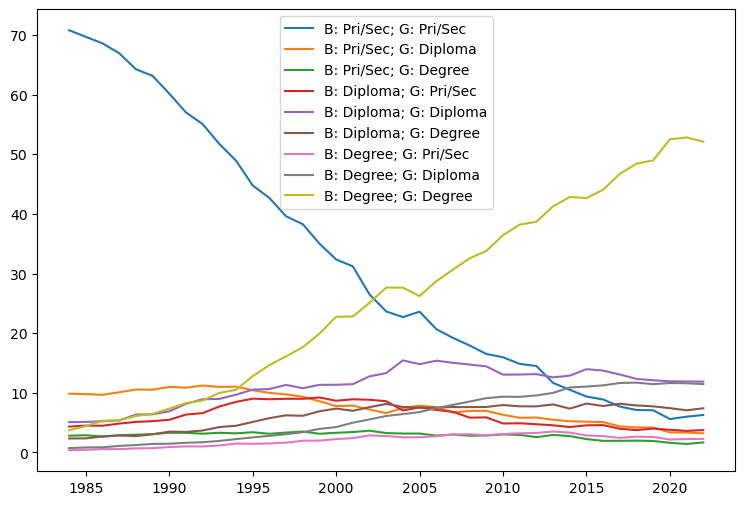

In [118]:
df_m_p = df_m.div(df_m.sum(axis=1), axis=0).mul(100).copy(deep=True)
plt.figure(figsize=(9, 6))
plt.plot(df_m_p)
plt.legend([f'B: {b}; G: {g}' for b, g in df_m_p.columns.to_flat_index()], loc=9)
plt.show()
plt.gcf().clear()
plt.close(plt.gcf())

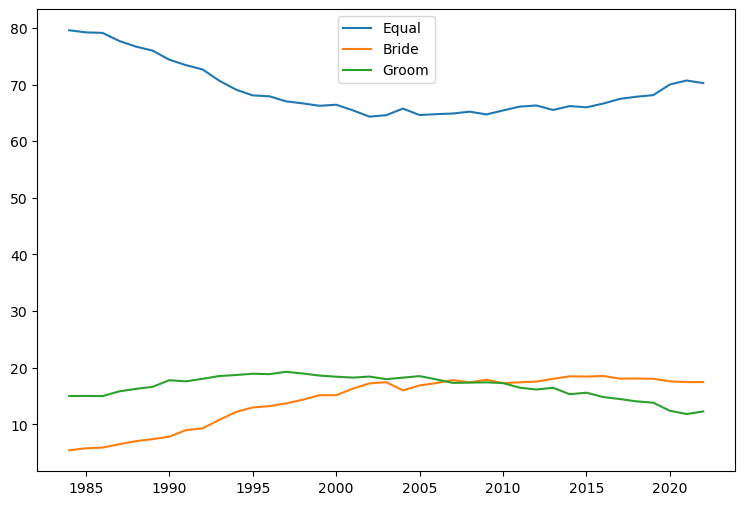

In [117]:
df_m_p_simp = pd.DataFrame.from_dict(
    {
        'Equal': df_m_p.loc[:,df_m_p.columns.get_level_values('Brides')==df_m_p.columns.get_level_values('Grooms')].sum(axis=1), 
        'Bride': df_m_p.loc[:,df_m_p.columns.get_level_values('Brides')>df_m_p.columns.get_level_values('Grooms')].sum(axis=1), 
        'Groom': df_m_p.loc[:,df_m_p.columns.get_level_values('Brides')<df_m_p.columns.get_level_values('Grooms')].sum(axis=1), 
    }, 
    orient='columns'
)
plt.figure(figsize=(9, 6))
plt.plot(df_m_p_simp)
plt.legend(df_m_p_simp.columns, loc=9)
plt.show()
plt.gcf().clear()
plt.close(plt.gcf())

/tmp/ipykernel_924/2974830437.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_m_p_b:pd.DataFrame = df_m.stack(level=['Grooms']).copy(deep=True)


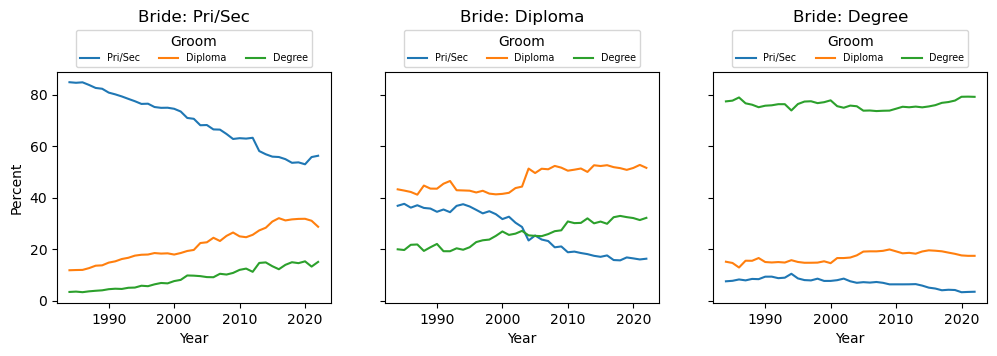

In [116]:
df_m_p_b:pd.DataFrame = df_m.stack(level=['Grooms']).copy(deep=True)
df_m_p_b = df_m_p_b.div(df_m_p_b.groupby(by=['Year']).sum()).mul(100)
_, axs = plt.subplots(1, 3, figsize=(12,3), sharey=True)
for i in range(3):
    sns.lineplot(data=df_m_p_b, x='Year', y=df_m_p_b.columns[i], hue='Grooms', ax=axs[i])
    axs[i].legend(title='Groom', loc=8, bbox_to_anchor=(0.5, 1), ncols=3, fontsize='x-small')
    axs[i].set_ylabel('Percent')
    axs[i].set_title(f'Bride: {df_m_p_b.columns[i]}', pad=36)
plt.show()
plt.gcf().clear()
plt.close(plt.gcf())

/tmp/ipykernel_924/2238162695.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_m_p_g:pd.DataFrame = df_m.stack(level=['Brides']).copy(deep=True)


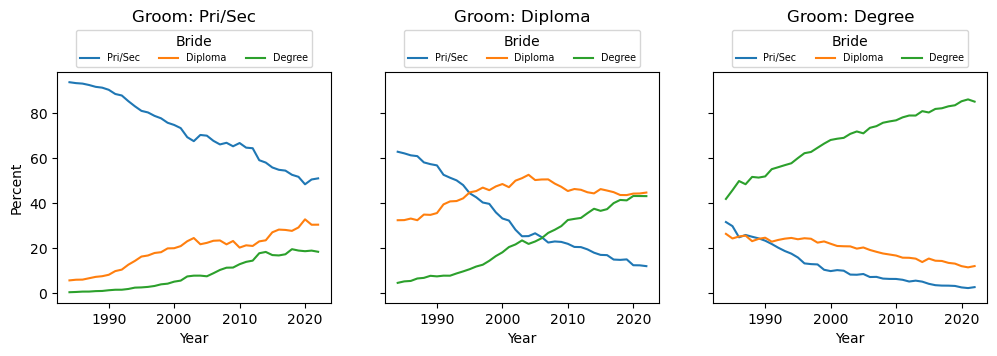

In [115]:
df_m_p_g:pd.DataFrame = df_m.stack(level=['Brides']).copy(deep=True)
df_m_p_g = df_m_p_g.div(df_m_p_g.groupby(by=['Year']).sum()).mul(100)
_, axs = plt.subplots(1, 3, figsize=(12,3), sharey=True)
for i in range(3):
    sns.lineplot(data=df_m_p_g, x='Year', y=df_m_p_g.columns[i], hue='Brides', ax=axs[i])
    axs[i].legend(title='Bride', loc=8, bbox_to_anchor=(0.5, 1), ncols=3, fontsize='x-small')
    axs[i].set_ylabel('Percent')
    axs[i].set_title(f'Groom: {df_m_p_g.columns[i]}', pad=36)
plt.show()
plt.gcf().clear()
plt.close(plt.gcf())

In addition to basic statistics, we can run basic inferential tests:
1.  Association tests:\
    These follow the same intuition as the basic chi-square tests of association.
    For these tests,\
    1 = perfect association, 0 = no association.\
    Which means that the test statistic can be interpreted as a scale.
2.  Correlation tests:\
    These differ from association tests in the sense that the test statistic has a sign and the sign is meaningful.\
    1 = perfect positive association, 0 = no association, -1 = perfect negative association.\
    By definition, correlation tests can only be used on ordered variables (which we have here).

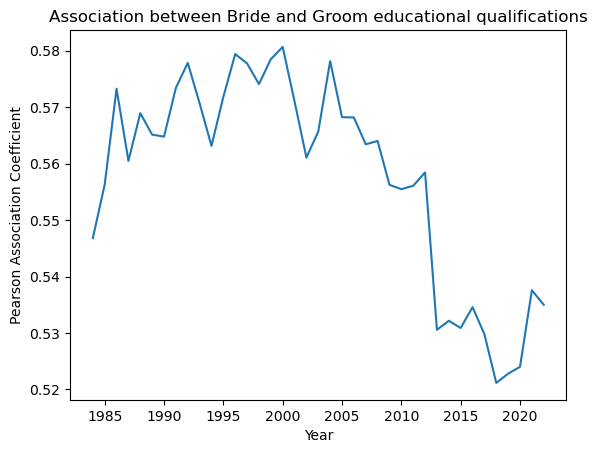

In [114]:
sns.lineplot(df_m.apply(lambda row: sps.contingency.association(row.unstack(level=['Grooms']), method='pearson'), axis=1))
plt.title('Association between Bride and Groom educational qualifications')
plt.ylabel('Pearson Association Coefficient')
plt.show()
plt.gcf().clear()
plt.close(plt.gcf())

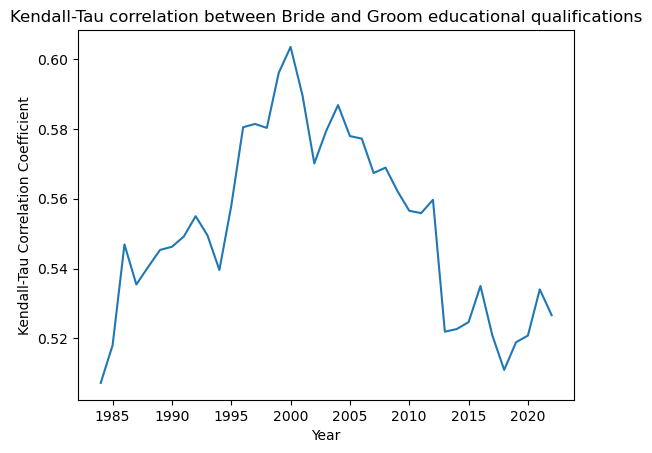

In [113]:
def _kendalltau_contingency(contingency_table:pd.Series|pd.DataFrame):
    if isinstance(contingency_table, pd.DataFrame):
        contingency_table = contingency_table.melt(ignore_index=False).set_index(keys=contingency_table.columns.names, append=True)['value']
    assert contingency_table.index.nlevels == 2, 'Works only on 2-dimensional contingency tables!'
    try:
        contingency_table = pd.to_numeric(contingency_table, downcast='integer', errors='raise')
    except:
        raise TypeError('Contingency Tables are count tables')
    assert pd.api.types.is_integer_dtype(contingency_table), ''
    contingency_table = contingency_table.repeat(contingency_table)
    contingency_table = contingency_table.index.to_frame(index=False)
    contingency_table = contingency_table.stack(future_stack=True).rank(method='min')
    contingency_table = contingency_table.unstack()
    result = sps.kendalltau(*contingency_table.to_numpy().T)
    return result.statistic
sns.lineplot(df_m.apply(lambda row: _kendalltau_contingency(row), axis=1))
plt.title('Kendall-Tau correlation between Bride and Groom educational qualifications')
plt.ylabel('Kendall-Tau Correlation Coefficient')
plt.show()
plt.gcf().clear()
plt.close(plt.gcf())

These basic statistics show 2 main stories:
1.  Positive Assortative Matching:\
    The most common kind of marriage is between people with similar education levels.
    In fact the level of matching is above chance levels.
    Either, one can see that the by-groom-level and by-bride-level proportions cannot be true under independent matching since then the proportions will have to be identical for all levels of bride/groom education,
    or one can also see from the association and correlation tests that sorting in Singapore's marriage market exhibits very high positive sortation.
2.  Increasing womens' education levels:\
    First, with non-equal marriages, the proportion of marriages with higher bride qualifications increases while the proportion with higher groom qualification falls.
    Second, under the by-groom-qualification sub-plots, all cases of brides having lower qualification decrease over time while all cases of brides having higher qualification increase.

Over time, there is another interesting story:
1.  While positive assortative matching is high, it has not been increasing and may be trending down in recent years.

These trends together seemingly imply some structure to how the dating and marriage markets that has not changed substantially in the past 4 decades.

### B.  Marriages by Age Groups

In [110]:
datasets.search([r'(?i:marriage)', r'(?i:\bage)', r'(?i:muslim)'], [False, False, True])

{'d_1c7a6c900300410dfb723927da7b3636': "First Marriages For Brides Under The Women's Charter By Age Group Of Grooms And Brides, Annual",
 'd_9fe2e79545bc18d80a1ea5cde8aa8b24': "Marriages Under The Women's Charter By Age Group Of Grooms, Annual",
 'd_7e58d5b4e06fbb22d958ed13761aa8d0': "Marriages Under The Women's Charter By Age Group Of Brides, Annual",
 'd_e42526ed15108b310f9efe5077bca27a': "Divorces Under The Women's Charter By Age At Marriage Of Male And Female Divorcees, Annual",
 'd_4a6347a51983571d5a5ccfda425266ed': "Marriages Under The Women's Charter By Age Group Of Grooms And Brides, Annual",
 'd_6cba526492c2b80c855323165af4cc94': 'Total Marriages By Age Differential Of Grooms To Brides And Marriage Order, Annual',
 'd_2a589767aadd5550f887fe0005b9ba7e': "Annulments Under The Women's Charter By Duration Of Marriage, Age Group And Sex, Annual",
 'd_3e90aefaff9a8ec5b7d9d39f8dd53306': "Divorces Under The Women's Charter By Age At Marriage, Ethnic Group And Sex Of Divorcees, Annual"

Load the marriages by age groups dataset and reshape it to make sense.

In [111]:
df_a = datasets.retrieve_dataset('d_4a6347a51983571d5a5ccfda425266ed')
df_a = df_a.sort_values(by=['_id'])
df_a['Brides'] = df_a['DataSeries'].str.extract(r'(?i:brides?\W+\b(.+)\b)', expand=True).ffill()
df_a['Grooms'] = df_a['DataSeries'].str.extract(r'(?i:grooms?\W+\b(.+)\b)', expand=True)
df_a = df_a.dropna(subset=['Brides', 'Grooms'], how='any')
df_a = df_a.drop(columns=['_id', 'DataSeries'])
df_a['Brides'] = df_a['Brides'].str.replace(r'(?i:aged?|years?)', '', regex=True).str.strip()
df_a['Brides'] = df_a['Brides'].str.replace(r'(?i:under)', '<', regex=True).str.strip()
df_a['Brides'] = df_a['Brides'].str.replace(r'(?i:\W+over)', '+', regex=True).str.strip()
df_a['Grooms'] = df_a['Grooms'].str.replace(r'(?i:aged?|years?)', '', regex=True).str.strip()
df_a['Grooms'] = df_a['Grooms'].str.replace(r'(?i:under)', '<', regex=True).str.strip()
df_a['Grooms'] = df_a['Grooms'].str.replace(r'(?i:\W+over)', '+', regex=True).str.strip()
df_a['Brides'] = pd.Categorical(df_a['Brides'], categories=['< 20', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60+'], ordered=True)
df_a['Grooms'] = pd.Categorical(df_a['Grooms'], categories=['< 20', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60+'], ordered=True)
df_a = df_a.set_index(keys=['Brides', 'Grooms'], append=False)
df_a = df_a.rename_axis(columns=['Year'])
df_a = df_a.transpose().sort_index(axis=0).sort_index(axis=1)
df_a

Brides < 20                                                      ...  60+  \
Grooms < 20 20-24 25-29 30-34 35-39 40-44 45-49 50-54 55-59 60+  ... < 20   
Year                                                             ...        
1983     65   811   417    48     4     1     0     0     0   0  ...    0   
1984     49   718   350    56     9     2     0     0     0   0  ...    0   
1985     52   671   304    44     7     1     1     0     0   0  ...    0   
1986     47   488   242    39     4     1     1     0     0   0  ...    0   
1987     46   513   241    43     5     1     1     0     0   0  ...    0   
1988     40   451   246    54     7     3     1     0     0   0  ...    0   
1989     46   418   232    55     6     1     2     0     0   0  ...    0   
1990     56   364   274    63     4     3     1     0     0   0  ...    0   
1991     68   321   246    66     7     6     1     1     0   0  ...    0   
1992     68   341   234    76    22     6     1     1     0   0  ...    0   
1993     57   276   187    74    15     3     0     0     1   0  ...    0   
1994     55   227   154    66    14     3     0     0     0   0  ...    0   
1995     45   221   143    66    14     3     1     0     0   0  ...    0   
1996     50   231   127    45    18     3     1     0     0   0  ...    0   
1997     41   222   103    43    13     3     0     0     0   0  ...    0   
1998     50   237   152    49    17     8     1     0     0   0  ...    0   
1999     60   214   148    52    16     4     2     0     0   0  ...    0   
2000     67   205   136    28     9     5     1     1     0   0  ...    0   
2001     71   180   120    31    18     6     2     0     0   0  ...    0   
2002     49   155    94    32    16     7     2     1     1   0  ...    0   
2003     40   136    66    22    11     6     4     6     2   1  ...    0   
2004     29   144    64    38    19    14     6     5     2   1  ...    0   
2005     37   133    64    49    36    43    29     6     5   1  ...    0   
2006     34   119    66    40    41    28    18     4     4   0  ...    0   
2007     43   128    74    32    32    30    20    12     6   3  ...    0   
2008     37   116    62    36    36    27    11     8     4   1  ...    0   
2009     39   102    60    43    40    19    19     8     5   1  ...    0   
2010     50   107    56    26    22    15     8     5     2   1  ...    0   
2011     41    99    36    32    21     7    14     6     3   0  ...    0   
2012     35    80    38    27    18     9     7     3     0   5  ...    0   
2013     38    77    44    15    13    11     2     4     1   1  ...    0   
2014     19    64    24    17    15     3     3     4     3   0  ...    0   
2015     12    51    24    17    15     9     3     1     1   0  ...    0   
2016     16    44    20    16    12     7     2     2     0   0  ...    0   
2017     18    39    17    10     4     2     1     1     1   0  ...    0   
2018      9    30    15     2     2     3     1     0     0   0  ...    0   
2019     13    24    10     3     4     2     0     0     0   1  ...    0   
2020      8    33     9     5     1     2     1     0     0   0  ...    0   
2021      8    27     6     3     1     1     0     0     0   0  ...    0   
2022      4    27     8     5     2     1     1     0     0   0  ...    0   

Brides                                                      
Grooms 20-24 25-29 30-34 35-39 40-44 45-49 50-54 55-59 60+  
Year                                                        
1983       0     0     0     0     0     0     0     2   7  
1984       0     0     0     0     0     0     1     1   5  
1985       0     0     0     0     0     0     0     0   4  
1986       0     0     0     0     0     0     0     0   1  
1987       0     0     0     0     0     1     0     1  12  
1988       0     0     0     0     0     1     0     0   8  
1989       0     0     0     0     0     0     0     3   5  
1990       0     0     1     0     0     0     0     0   6  
1991       0     

Basic statistics:
1.  Proportion Equal-Age-Group Marriages.
2.  Proportion of Marriages by Bride-Groom Age Differential.
3.  Proportion of Groom age groups by Bride age groups.
4.  Proportion of Bride age groups by Groom age groups.